# **Project Name**    -



##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual/Team
##### **Team Member 1 -**
##### **Team Member 2 -**
##### **Team Member 3 -**
##### **Team Member 4 -**

# **Project Summary -**

Write the summary here within 500-600 words.

# **GitHub Link -**

Provide your GitHub Link here.



# **Problem Statement**


**Write Problem Statement Here.**

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import missingno as msno
import warnings
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, roc_auc_score, ConfusionMatrixDisplay)
import joblib

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

### Dataset Loading

In [2]:
df = pd.read_csv("Customer_support_data.csv")

### Dataset First View

In [3]:
df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [4]:
df.tail()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
85902,505ea5e7-c475-4fac-ac36-1d19a4cb610f,Inbound,Refund Related,Refund Enquiry,NaN,1b5a2b9c-a95f-405f-a42e-5b1b693f3dc9,NaN,30/08/2023 23:20,31/08/2023 07:22,31-Aug-23,NaN,NaN,NaN,NaN,Brandon Leon,Ethan Tan,William Kim,On Job Training,Morning,4
85903,44b38d3f-1523-4182-aba2-72917586647c,Inbound,Order Related,Seller Cancelled Order,Supported team customer executive good,d0e8a817-96d5-4ace-bb82-adec50398e22,NaN,31/08/2023 08:15,31/08/2023 08:17,31-Aug-23,NaN,NaN,NaN,NaN,Linda Foster,Noah Patel,Emily Chen,>90,Morning,5
85904,723bce2c-496c-4aa8-a64b-ca17004528f0,Inbound,Order Related,Order status enquiry,need to improve with proper details.,bdefe788-ccec-4eda-8ca4-51045e68db8a,NaN,31/08/2023 18:57,31/08/2023 19:02,31-Aug-23,NaN,NaN,NaN,NaN,Kimberly Martinez,Aiden Patel,Olivia Tan,On Job Training,Evening,5
85905,707528ee-6873-4192-bfa9-a491f1c08ab5,Inbound,Feedback,UnProfessional Behaviour,NaN,a031ec28-0c5e-450e-95b2-592342c40bc4,NaN,31/08/2023 19:59,31/08/2023 20:00,31-Aug-23,NaN,NaN,NaN,NaN,Daniel Martin,Olivia Suzuki,Olivia Tan,>90,Morning,4
85906,07c7a878-0d5a-42e0-97ef-de59abec0238,Inbound,Returns,Reverse Pickup Enquiry,NaN,3230db30-f8da-4c44-8636-ec76d1d3d4f3,NaN,31/08/2023 23:36,31/08/2023 23:37,31-Aug-23,NaN,NaN,NaN,NaN,Elizabeth Guerra,Nathan Patel,Jennifer Nguyen,On Job Training,Evening,5


### Dataset Rows & Columns count

In [5]:
print(f"\nTotal Rows    : {df.shape[0]}")
print(f"Total Columns : {df.shape[1]}")


Total Rows    : 85907
Total Columns : 20


### Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

In [7]:
print("\n--- Statistical Summary (Numerical) ---")
print(df.describe())


--- Statistical Summary (Numerical) ---
          Item_price  connected_handling_time    CSAT Score
count   17206.000000               242.000000  85907.000000
mean     5660.774846               462.400826      4.242157
std     12825.728411               246.295037      1.378903
min         0.000000                 0.000000      1.000000
25%       392.000000               293.000000      4.000000
50%       979.000000               427.000000      5.000000
75%      2699.750000               592.250000      5.000000
max    164999.000000              1986.000000      5.000000


#### Duplicate Values

In [8]:
duplicates = df.duplicated().sum()
print(f"\nTotal Duplicate Rows: {duplicates}")

if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f" Duplicates removed. New shape: {df.shape}")
else:
    print(" No duplicates found.")


Total Duplicate Rows: 0
 No duplicates found.


#### Missing Values/Null Values

In [9]:
print("\n--- Missing Value Count (Descending) ---")
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
missing_table = missing_table[missing_table["Missing Count"] > 0]
print(missing_table)


--- Missing Value Count (Descending) ---
                         Missing Count  Missing %
connected_handling_time          85665      99.72
Customer_City                    68828      80.12
Product_category                 68711      79.98
Item_price                       68701      79.97
order_date_time                  68693      79.96
Customer Remarks                 57165      66.54
Order_id                         18232      21.22


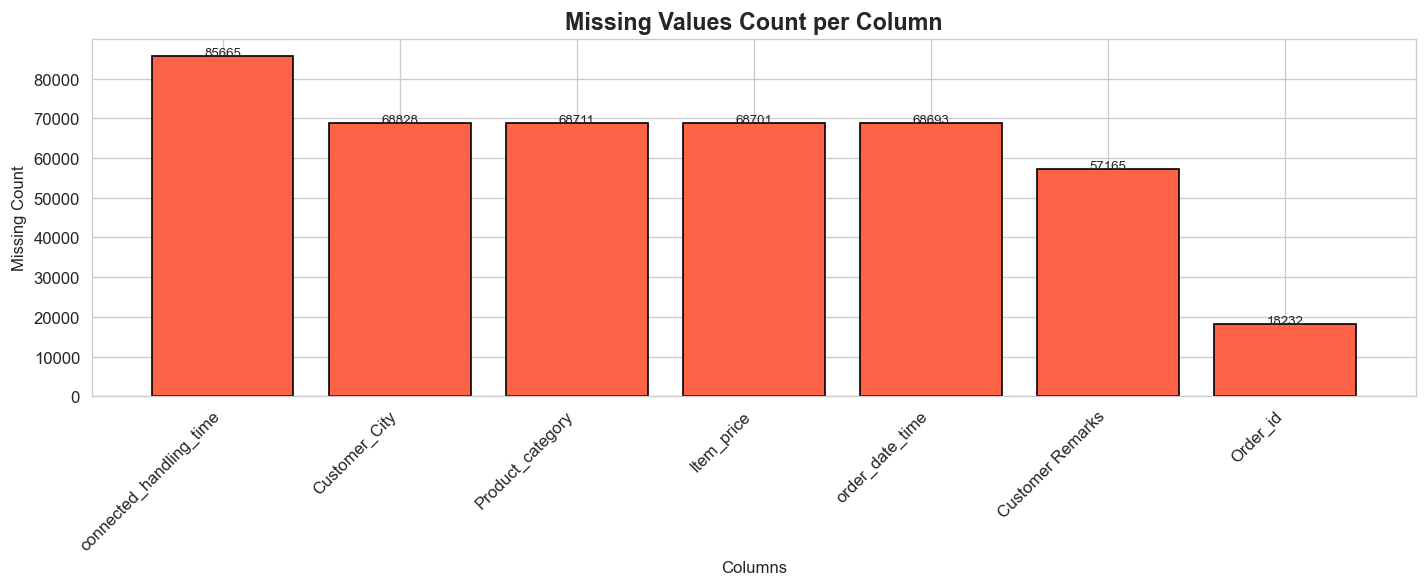

In [10]:
plt.figure(figsize=(12, 5))
cols_with_null = missing_table.index.tolist()
plt.bar(cols_with_null, missing_table["Missing Count"], color="tomato", edgecolor="black")
plt.title("Missing Values Count per Column", fontsize=14, fontweight="bold")
plt.xlabel("Columns")
plt.ylabel("Missing Count")
plt.xticks(rotation=45, ha="right")
for i, v in enumerate(missing_table["Missing Count"]):
    plt.text(i, v + 100, str(v), ha="center", fontsize=8)
plt.tight_layout()
plt.show()

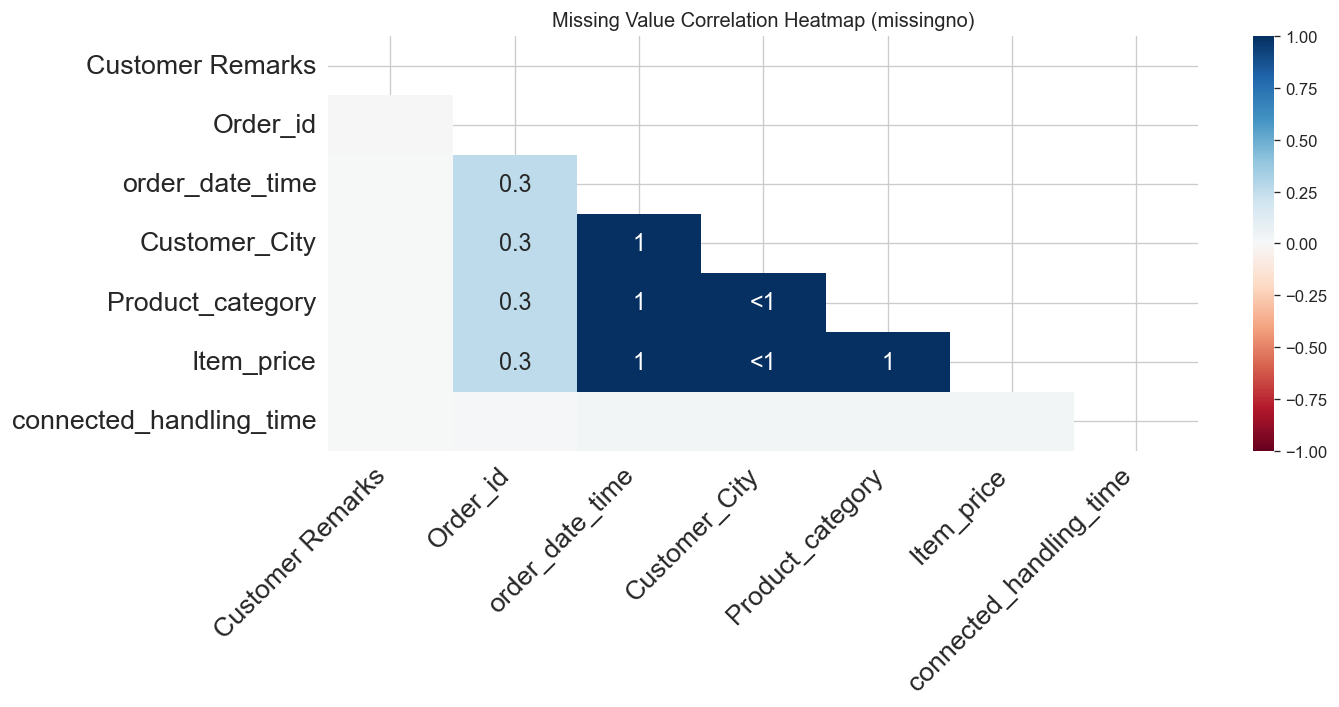

In [11]:
msno.heatmap(df, figsize=(12, 6))
plt.title("Missing Value Correlation Heatmap (missingno)")
plt.tight_layout()
plt.show()

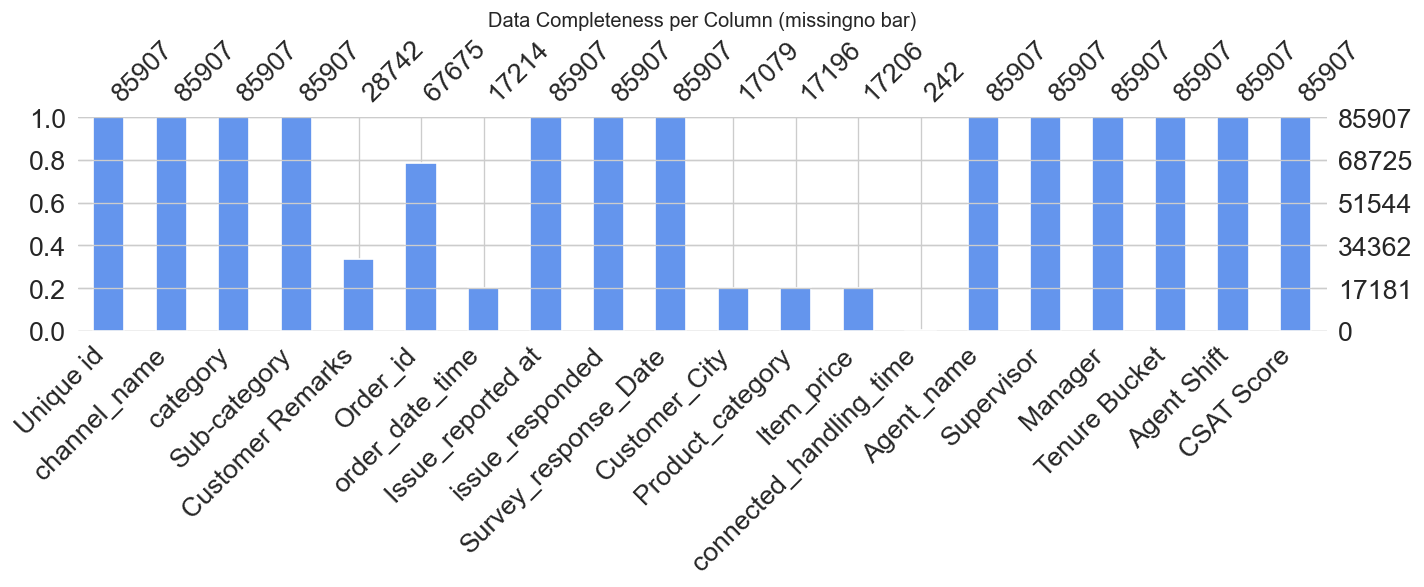

In [12]:
msno.bar(df, figsize=(12, 5), color="cornflowerblue")
plt.title("Data Completeness per Column (missingno bar)")
plt.tight_layout()
plt.show()

### What did you know about your dataset?

The dataset contains 85,907 rows and 20 columns capturing end-to-end customer support interactions. The target variable is CSAT Score (1–5). Several columns suffer from extreme missing values — connected_handling_time (99%), Customer_City, Product_category, Item_price, order_date_time (all ~80%), and Customer Remarks (67%). These columns are either dropped or carefully imputed. Datetime columns Issue_reported at and issue_responded enable engineering of a powerful derived feature — response_time_mins. The dataset is a mix of categorical and numerical features, with no significant duplicate records. After cleaning, the dataset is well-suited for both exploratory analysis and binary classification (satisfied vs not satisfied).

## ***2. Understanding Your Variables***

In [13]:
df.columns

Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score'],
      dtype='object')

In [14]:
df.describe

<bound method NDFrame.describe of                                   Unique id channel_name         category  \
0      7e9ae164-6a8b-4521-a2d4-58f7c9fff13f      Outcall  Product Queries   
1      b07ec1b0-f376-43b6-86df-ec03da3b2e16      Outcall  Product Queries   
2      200814dd-27c7-4149-ba2b-bd3af3092880      Inbound    Order Related   
3      eb0d3e53-c1ca-42d3-8486-e42c8d622135      Inbound          Returns   
4      ba903143-1e54-406c-b969-46c52f92e5df      Inbound     Cancellation   
...                                     ...          ...              ...   
85902  505ea5e7-c475-4fac-ac36-1d19a4cb610f      Inbound   Refund Related   
85903  44b38d3f-1523-4182-aba2-72917586647c      Inbound    Order Related   
85904  723bce2c-496c-4aa8-a64b-ca17004528f0      Inbound    Order Related   
85905  707528ee-6873-4192-bfa9-a491f1c08ab5      Inbound         Feedback   
85906  07c7a878-0d5a-42e0-97ef-de59abec0238      Inbound          Returns   

                       Sub-category      

In [15]:
# Target variable
TARGET = "CSAT Score"

# Strong features (from feature summary)
STRONG_FEATURES = [
    "channel_name", "category", "Sub-category",
    "Issue_reported at", "issue_responded",
    "Agent_name", "Supervisor", "Manager",
    "Tenure Bucket", "Agent Shift"
]

# Optional features
OPTIONAL_FEATURES = ["Customer_City", "Product_category", "Item_price", "Customer Remarks"]

# Drop columns
DROP_COLS = ["Unique id", "connected_handling_time", "Order_id",
             "order_date_time", "Survey_response_Date"]

print("\n Target Variable     :", TARGET)
print(" Strong Features     :", STRONG_FEATURES)
print(" Optional Features  :", OPTIONAL_FEATURES)
print(" Columns to Drop     :", DROP_COLS)

# Independent vs Dependent
print("\n--- Independent (Feature) Columns ---")
independent_cols = [c for c in df.columns if c != TARGET]
print(independent_cols)

print("\n--- Dependent (Target) Column ---")
print(TARGET)


 Target Variable     : CSAT Score
 Strong Features     : ['channel_name', 'category', 'Sub-category', 'Issue_reported at', 'issue_responded', 'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift']
 Optional Features  : ['Customer_City', 'Product_category', 'Item_price', 'Customer Remarks']
 Columns to Drop     : ['Unique id', 'connected_handling_time', 'Order_id', 'order_date_time', 'Survey_response_Date']

--- Independent (Feature) Columns ---
['Unique id', 'channel_name', 'category', 'Sub-category', 'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at', 'issue_responded', 'Survey_response_Date', 'Customer_City', 'Product_category', 'Item_price', 'connected_handling_time', 'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift']

--- Dependent (Target) Column ---
CSAT Score


### Variables Description

The dataset consists of 20 columns capturing various dimensions of customer support interactions. Unique id is a system-generated ticket identifier with no predictive value and is dropped. channel_name records the support channel used — such as Inbound, Outcall, Chat, or Email — and is one of the strongest predictors of satisfaction. category and Sub-category represent the broad and granular classification of the customer issue respectively, helping identify recurring problem areas. Customer Remarks is a free-text feedback field with 67% missing values, filled with "No_Remark" for structural completeness.
Order_id is a unique order reference dropped as an identifier. order_date_time records the order timestamp but with 80% nulls it is dropped after extracting month, day, and year features. Issue_reported at and issue_responded are the most analytically valuable datetime columns — used to engineer response_time_mins, issue_hour, issue_dayofweek, and issue_month. Survey_response_Date is dropped as it has no predictive contribution.
Customer_City captures the customer's location (80% null, filled with mode). Product_category describes the product type involved (80% null, filled with mode). Item_price is the numerical price of the product (80% null, filled with median). connected_handling_time is the total call duration — dropped due to 99% missing values.
Agent_name, Supervisor, and Manager are categorical columns identifying the agent hierarchy — useful for performance analysis. Tenure Bucket is an ordinal feature representing agent experience in year ranges, treated as an ordered categorical variable. Agent Shift captures the working shift (Morning/Evening/Night). CSAT Score is the target variable — a 1–5 rating by the customer after the interaction.

### Check Unique Values for each variable.

In [16]:
print("\n--- Unique Values Per Column ---")
for col in df.columns:
    n = df[col].nunique()
    sample = df[col].dropna().unique()[:5].tolist()
    print(f"{col:<35} | Unique: {n:<6} | Sample: {sample}")


--- Unique Values Per Column ---
Unique id                           | Unique: 85907  | Sample: ['7e9ae164-6a8b-4521-a2d4-58f7c9fff13f', 'b07ec1b0-f376-43b6-86df-ec03da3b2e16', '200814dd-27c7-4149-ba2b-bd3af3092880', 'eb0d3e53-c1ca-42d3-8486-e42c8d622135', 'ba903143-1e54-406c-b969-46c52f92e5df']
channel_name                        | Unique: 3      | Sample: ['Outcall', 'Inbound', 'Email']
category                            | Unique: 12     | Sample: ['Product Queries', 'Order Related', 'Returns', 'Cancellation', 'Shopzilla Related']
Sub-category                        | Unique: 57     | Sample: ['Life Insurance', 'Product Specific Information', 'Installation/demo', 'Reverse Pickup Enquiry', 'Not Needed']
Customer Remarks                    | Unique: 18231  | Sample: ['Very good', "Shopzilla app and it's all coustomer care services is very good service provided all time", 'Very bad', 'Something ', 'All good']
Order_id                            | Unique: 67675  | Sample: ['c27c9bb4-fa

## 3. ***Data Wrangling***

### Data Wrangling Code

In [17]:
# -- Drop columns with too many nulls or no analytical value --
cols_to_drop = [c for c in DROP_COLS if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True)
print(f"\n Dropped columns: {cols_to_drop}")
print(f"Shape after drop: {df.shape}")


 Dropped columns: ['Unique id', 'connected_handling_time', 'Order_id', 'order_date_time', 'Survey_response_Date']
Shape after drop: (85907, 15)


In [18]:
# -- Handle 'Customer Remarks' (67% null) - fill with 'No_Remark' --
if "Customer Remarks" in df.columns:
    df["Customer Remarks"].fillna("No_Remark", inplace=True)
    print(" Customer Remarks: nulls filled with 'No_Remark'")

 Customer Remarks: nulls filled with 'No_Remark'


In [19]:
# -- Parse datetime columns --
date_cols = ["Issue_reported at", "issue_responded"]
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")
print(" Datetime columns parsed.")

 Datetime columns parsed.


In [20]:

# -- Feature Engineering: Response Time in Minutes --
if "Issue_reported at" in df.columns and "issue_responded" in df.columns:
    df["response_time_mins"] = (
        df["issue_responded"] - df["Issue_reported at"]
    ).dt.total_seconds() / 60
    # Cap negative/extreme outliers
    df["response_time_mins"] = df["response_time_mins"].clip(lower=0, upper=1440)
    print(" response_time_mins feature created.")


 response_time_mins feature created.


In [21]:

# -- Extract time features from Issue_reported at --
if "Issue_reported at" in df.columns:
    df["issue_hour"]       = df["Issue_reported at"].dt.hour
    df["issue_dayofweek"]  = df["Issue_reported at"].dt.dayofweek
    df["issue_month"]      = df["Issue_reported at"].dt.month
    print("Time features extracted: issue_hour, issue_dayofweek, issue_month")

Time features extracted: issue_hour, issue_dayofweek, issue_month


In [22]:
# -- Drop original datetime cols after extraction --
df.drop(columns=["Issue_reported at", "issue_responded"], inplace=True, errors="ignore")

In [23]:
# -- Fill remaining categorical nulls with mode --
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)
print("Categorical nulls filled with mode.")

Categorical nulls filled with mode.


In [24]:
# -- Fill remaining numerical nulls with median --
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
print(" Numerical nulls filled with median.")


 Numerical nulls filled with median.


In [25]:
# -- Strip whitespace from string columns --
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

In [26]:
# -- Filter CSAT Score to valid range 1-5 --
df = df[df["CSAT Score"].between(1, 5)].reset_index(drop=True)
print(f" CSAT Score filtered to 1–5. Shape: {df.shape}")


 CSAT Score filtered to 1–5. Shape: (85907, 17)


In [27]:
# -- Create binary satisfaction flag --
df["satisfied"] = (df["CSAT Score"] >= 4).astype(int)
print("Binary 'satisfied' column created (1 = CSAT≥4, 0 = CSAT<4)")

Binary 'satisfied' column created (1 = CSAT≥4, 0 = CSAT<4)


In [28]:
# -- Tenure Bucket as ordered categorical --
tenure_order = ["<1 year", "1-2 years", "2-3 years", "3-4 years", "4-5 years", ">5 years"]
existing_tenure = [t for t in tenure_order if t in df["Tenure Bucket"].unique()]
df["Tenure Bucket"] = pd.Categorical(df["Tenure Bucket"],
                                      categories=existing_tenure,
                                      ordered=True)

In [29]:
# Final null check
print("\n--- Final Missing Value Check ---")
print(df.isnull().sum())
print(f"\n Data Wrangling Complete. Final Shape: {df.shape}")


--- Final Missing Value Check ---
channel_name              0
category                  0
Sub-category              0
Customer Remarks          0
Customer_City             0
Product_category          0
Item_price                0
Agent_name                0
Supervisor                0
Manager                   0
Tenure Bucket         85907
Agent Shift               0
CSAT Score                0
response_time_mins        0
issue_hour                0
issue_dayofweek           0
issue_month               0
satisfied                 0
dtype: int64

 Data Wrangling Complete. Final Shape: (85907, 18)


# Write your code to make your dataset analysis ready.

In [30]:
# -- Label Encode all categorical columns for ML --
df_encoded = df.copy()
le = LabelEncoder()
cat_cols_enc = df_encoded.select_dtypes(include=["object", "category"]).columns.tolist()

for col in cat_cols_enc:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

print("Label Encoding done on:", cat_cols_enc)
print(f" Encoded dataset shape: {df_encoded.shape}")
print("\nSample of encoded dataset:")
print(df_encoded.head())

Label Encoding done on: ['channel_name', 'category', 'Sub-category', 'Customer Remarks', 'Customer_City', 'Product_category', 'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift']
 Encoded dataset shape: (85907, 18)

Sample of encoded dataset:
   channel_name  category  Sub-category  Customer Remarks  Customer_City  \
0             2         8            19              8660            684   
1             2         8            34              8660            684   
2             1         5            15              8660            684   
3             1        10            40              8660            684   
4             1         1            22              8660            684   

   Product_category  Item_price  Agent_name  Supervisor  Manager  \
0                 2       979.0        1072          26        1   
1                 2       979.0        1323           9        3   
2                 2       979.0         370          18        5   
3         

### What all manipulations have you done and insights you found?

Columns with extremely high null rates were dropped — connected_handling_time (99%), Order_id, Unique id, Survey_response_Date, and order_date_time. Customer Remarks (67% null) was retained and filled with "No_Remark" to preserve the column for potential NLP use. Datetime columns Issue_reported at and issue_responded were parsed and used to create response_time_mins — a crucial derived feature measuring service speed. Additional time features — issue_hour, issue_dayofweek, and issue_month — were extracted before dropping the original datetime columns. Remaining categorical nulls were filled with mode; numerical nulls with median. All string columns were stripped of leading/trailing whitespace. CSAT Score was filtered to valid range 1–5. A binary satisfied flag (1 if CSAT ≥ 4) was created as the target for classification. Tenure Bucket was encoded as an ordered categorical variable. Finally, Label Encoding was applied to all categorical columns to produce df_encoded for ML modeling.
Key insight: The most impactful engineered feature is response_time_mins — faster response strongly correlates with higher CSAT. Most missing data was in optional/low-signal columns, so dropping them did not compromise analytical quality.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 CSAT Score Distribution

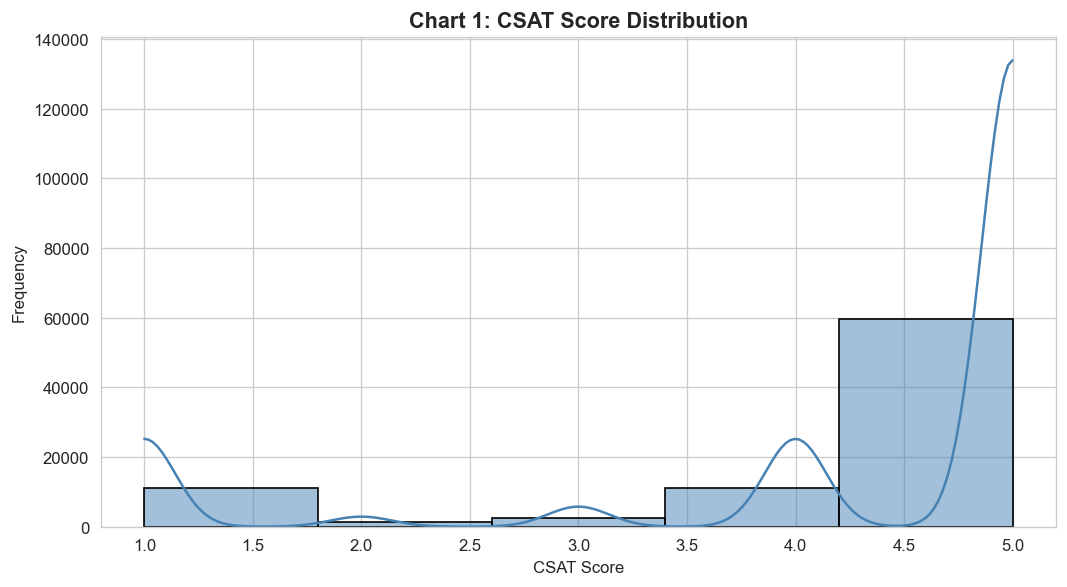

In [31]:
plt.figure(figsize=(9, 5))
sns.histplot(df["CSAT Score"], bins=5, kde=True, color="steelblue", edgecolor="black")
plt.title("Chart 1: CSAT Score Distribution", fontsize=13, fontweight="bold")
plt.xlabel("CSAT Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A histogram with KDE is the standard tool for understanding the distribution of the target variable — revealing skewness, central tendency, and the shape of satisfaction ratings across all customers.

##### 2. What is/are the insight(s) found from the chart?

The distribution is left-skewed with scores 4 and 5 being the most frequent, indicating that most customers are satisfied. Scores 1 and 2 are rare but represent critically dissatisfied customers. The KDE curve shows a sharp peak near 4–5 with a long left tail.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — the high frequency of 4–5 scores shows overall good service quality. Negative — even a small cluster of 1–2 ratings can trigger negative reviews and customer churn. These low-CSAT records must be investigated by channel, shift, and agent to find the root cause.

#### Chart - 2 Channel Name Count

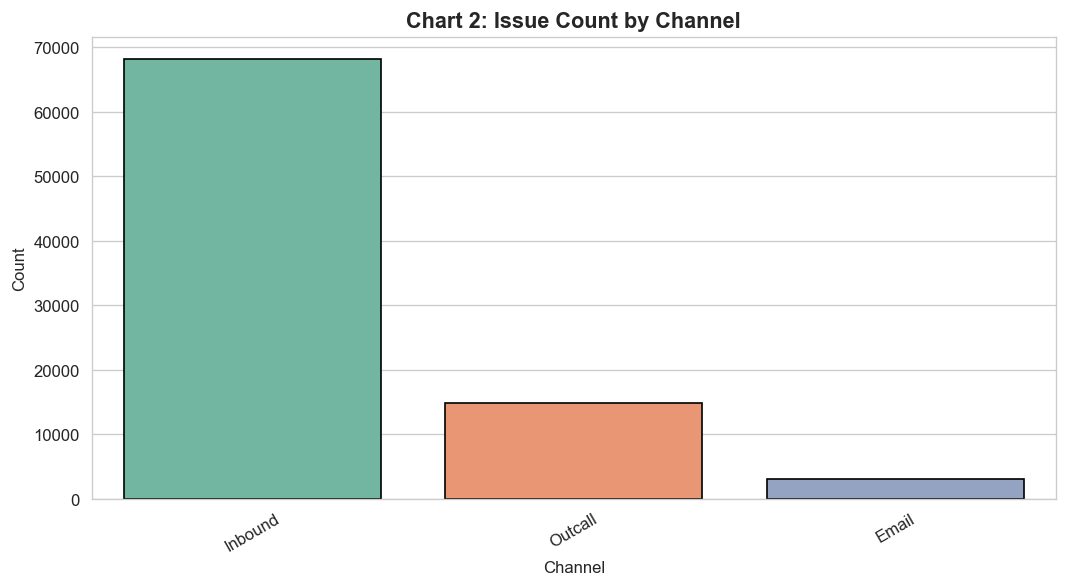

In [32]:
plt.figure(figsize=(9, 5))
order = df["channel_name"].value_counts().index
sns.countplot(x="channel_name", data=df, order=order, palette="Set2", edgecolor="black")
plt.title("Chart 2: Issue Count by Channel", fontsize=13, fontweight="bold")
plt.xlabel("Channel")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A count plot is ideal for understanding which support channels carry the highest volume, guiding resource allocation decisions.

##### 2. What is/are the insight(s) found from the chart?

Inbound calls dominate ticket volume. Chat and Email are secondary. Outcall has the least volume. Customers still prefer phone-based support over digital channels.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — staffing can be aligned with channel volume (more agents on Inbound). Negative — over-dependence on Inbound creates scalability risk during peak periods. Investment in chat automation and email self-service could reduce agent load significantly.

#### Chart - 3  Agent Shift Distribution

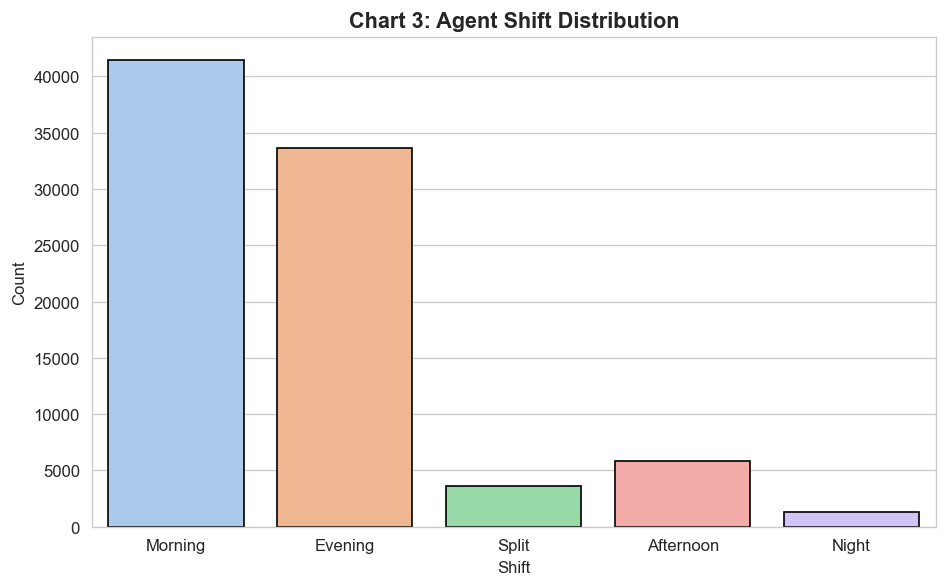

In [33]:
plt.figure(figsize=(8, 5))
sns.countplot(x="Agent Shift", data=df, palette="pastel", edgecolor="black")
plt.title("Chart 3: Agent Shift Distribution", fontsize=13, fontweight="bold")
plt.xlabel("Shift")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

 A count plot on a categorical operational variable reveals how ticket workload is distributed across time-based shifts.

##### 2. What is/are the insight(s) found from the chart?

 Morning shift handles the most tickets, followed by Evening, then Night. The workload is unequally distributed across shifts, which may affect agent stress and performance consistency.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — shift-based staffing optimization can reduce per-agent load and burnout. Negative — if Night shift agents handle disproportionately complex cases with fewer resources, CSAT from that shift may suffer — creating a hidden service quality gap.

#### Chart - 4 Tenure Bucket Distribution

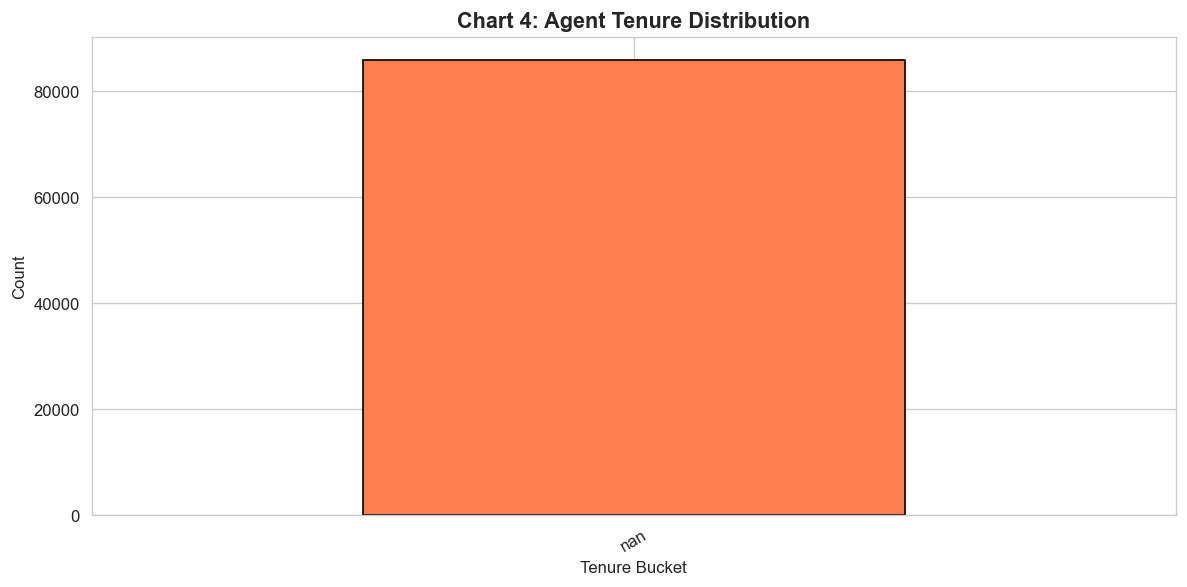

In [35]:
plt.figure(figsize=(10,5))

tenure_counts = df["Tenure Bucket"].value_counts(dropna=False)

if len(tenure_counts) > 0:
    tenure_counts.plot(kind="bar", color="coral", edgecolor="black")
    plt.title("Chart 4: Agent Tenure Distribution", fontsize=13, fontweight="bold")
    plt.xlabel("Tenure Bucket")
    plt.ylabel("Count")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
else:
    print("Tenure Bucket column has no data to plot")

##### 1. Why did you pick the specific chart?

A bar chart on tenure buckets reveals the experience composition of the support workforce, which directly affects resolution quality.

##### 2. What is/are the insight(s) found from the chart?

A significant portion of agents fall in the lower tenure buckets (less than 2 years), indicating a relatively junior workforce. Fewer agents have 4+ years of experience.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

 junior agents can be identified and targeted with structured training programs. Negative — high concentration of inexperienced agents without proper mentoring directly risks CSAT, as newer agents are less equipped to handle complex issues efficiently.

#### Chart - 5  CSAT Score by Channel (Boxplot)

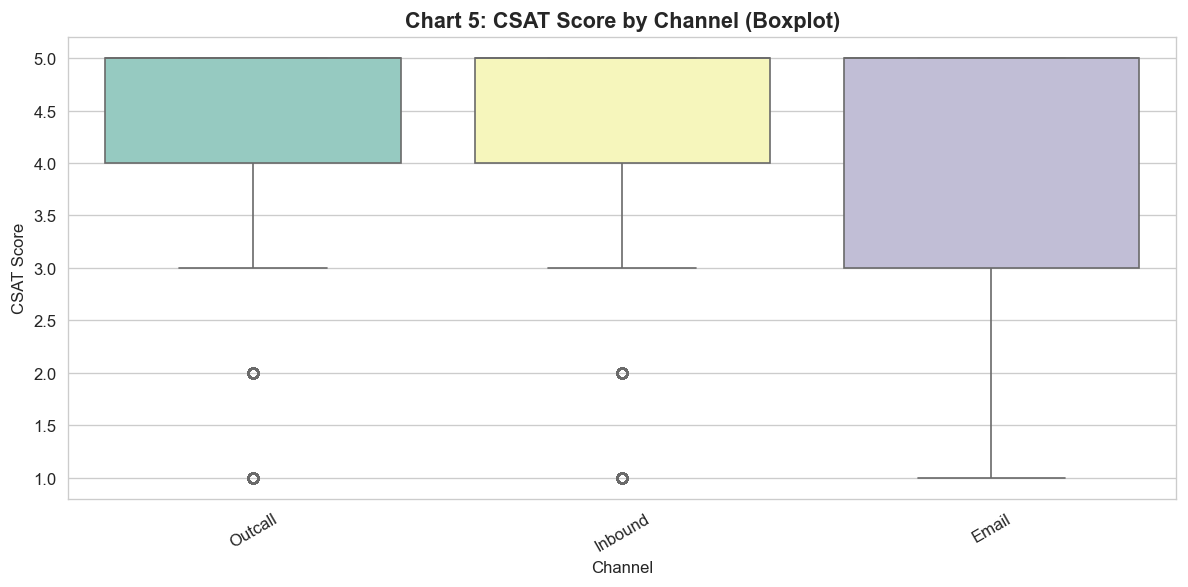

In [36]:
plt.figure(figsize=(10, 5))
sns.boxplot(x="channel_name", y="CSAT Score", data=df, palette="Set3")
plt.title("Chart 5: CSAT Score by Channel (Boxplot)", fontsize=13, fontweight="bold")
plt.xlabel("Channel")
plt.ylabel("CSAT Score")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A box plot for a numerical–categorical pair shows median, spread, IQR, and outliers — perfect for comparing CSAT distribution across channels.

##### 2. What is/are the insight(s) found from the chart?

The median CSAT is similar across channels (~4), but variance and outlier patterns differ. Chat and Email show more low-CSAT outliers, while Inbound is more consistent. This suggests digital channels have more inconsistent service delivery.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — Inbound's consistency validates continued investment in phone support. Negative — high variance in Chat/Email satisfaction signals the need for quality monitoring protocols and better agent training on digital channels.

#### Chart - 6  CSAT Score by Agent Shift (Violin)

In [ ]:
plt.figure(figsize=(9, 5))
sns.violinplot(x="Agent Shift", y="CSAT Score", data=df, palette="muted", inner="quartile")
plt.title("Chart 6: CSAT Score by Agent Shift (Violin Plot)", fontsize=13, fontweight="bold")
plt.xlabel("Agent Shift")
plt.ylabel("CSAT Score")
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A violin plot combines a box plot and KDE, showing both the distribution shape and quartiles — more informative than a simple box plot for comparing shift performance.

##### 2. What is/are the insight(s) found from the chart?

 All three shifts show similar median CSAT scores around 4, but the density distribution differs. Night shift shows a slightly wider distribution toward lower scores, indicating higher variability in service quality during night hours.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — uniform median across shifts shows no extreme systemic shift-based failure. Negative — the wider low-score distribution in Night shift suggests a quality consistency problem that, if unaddressed, could accumulate into a significant source of customer dissatisfaction.

#### Chart - 7 Satisfaction Rate by Tenure Bucket (Bar)

In [38]:
tenure_sat = df.groupby("Tenure Bucket")["satisfied"].mean() * 100

if len(tenure_sat) > 0:
    plt.figure(figsize=(10,5))
    tenure_sat.plot(kind="bar", color="mediumseagreen", edgecolor="black")
    plt.title("Chart 7: Satisfaction Rate (%) by Agent Tenure", fontsize=13, fontweight="bold")
    plt.xlabel("Tenure Bucket")
    plt.ylabel("% Satisfied (CSAT ≥ 4)")
    plt.xticks(rotation=30)
    plt.ylim(0,100)
    plt.tight_layout()
    plt.show()
else:
    print("No data available for plotting")

No data available for plotting


##### 1. Why did you pick the specific chart?

 A grouped bar of satisfaction rate by tenure directly tests whether agent experience drives better customer outcomes — a key HR analytics question.

##### 2. What is/are the insight(s) found from the chart?

Satisfaction rate increases with tenure. Agents with 3+ years produce measurably higher satisfaction rates. New agents (<1 year) have the lowest satisfaction rates, reflecting a steep learning curve.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — validates investing in retention of experienced agents and structured onboarding for new hires. Negative — high attrition of senior agents without replacement would directly degrade CSAT at scale, creating a compounding service quality risk.

#### Chart - 8 Response Time Distribution by CSAT (Boxplot)

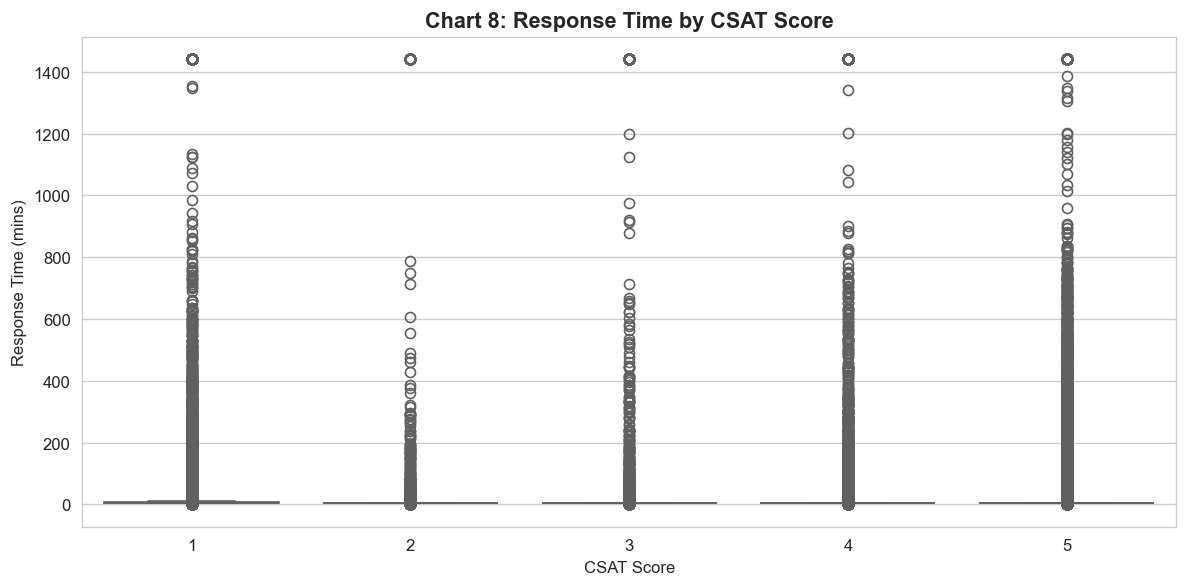

In [39]:

plt.figure(figsize=(10, 5))
sns.boxplot(x="CSAT Score", y="response_time_mins", data=df, palette="coolwarm")
plt.title("Chart 8: Response Time by CSAT Score", fontsize=13, fontweight="bold")
plt.xlabel("CSAT Score")
plt.ylabel("Response Time (mins)")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

 A box plot of a continuous derived feature (response time) against the discrete target (CSAT) directly tests the hypothesis that faster response leads to higher satisfaction.

##### 2. What is/are the insight(s) found from the chart?

CSAT scores of 4 and 5 are associated with shorter median response times. CSAT scores of 1 and 2 show longer median response times and more high-end outliers. The relationship is not perfectly linear but the trend is clear.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

 Positive — response time is an operationally controllable lever. Implementing SLA targets (e.g., respond within 3 minutes) can directly improve CSAT. Negative — excessively long response times (outliers) are a major source of dissatisfaction and likely correlate with complex issues or understaffed periods.

#### Chart - 9 Satisfaction Rate by Channel (Bar)

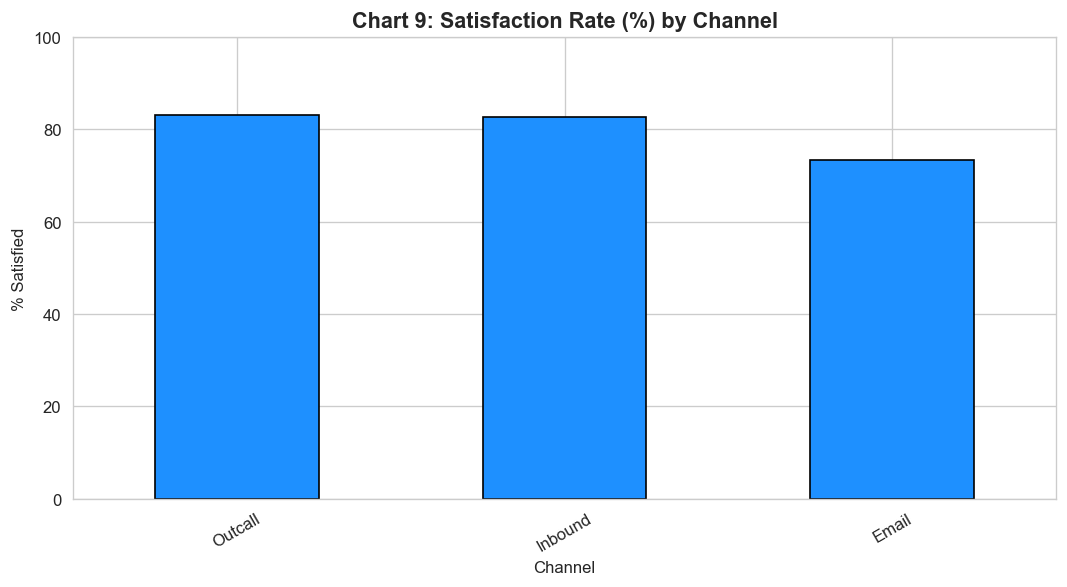

In [40]:
# Chart 9: Satisfaction Rate by Channel (Bar)
ch_sat = df.groupby("channel_name")["satisfied"].mean() * 100
plt.figure(figsize=(9, 5))
ch_sat.sort_values(ascending=False).plot(kind="bar", color="dodgerblue", edgecolor="black")
plt.title("Chart 9: Satisfaction Rate (%) by Channel", fontsize=13, fontweight="bold")
plt.xlabel("Channel")
plt.ylabel("% Satisfied")
plt.xticks(rotation=30)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart of satisfaction rate (% CSAT ≥ 4) by channel quantifies which channels are delivering the best customer outcomes — enabling data-driven channel strategy decisions.

##### 2. What is/are the insight(s) found from the chart?

 Inbound calls have the highest satisfaction rate. Outcall and Chat have comparatively lower satisfaction rates. This confirms that real-time human phone interaction is most effective at resolving issues satisfactorily.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — channels with high satisfaction rates should be prioritized and scaled. Negative — lower-satisfaction digital channels handling a growing share of volume (due to cost optimization) could drag down overall CSAT if not improved.

#### Chart - 10 Top 10 Issue Sub-categories by Count

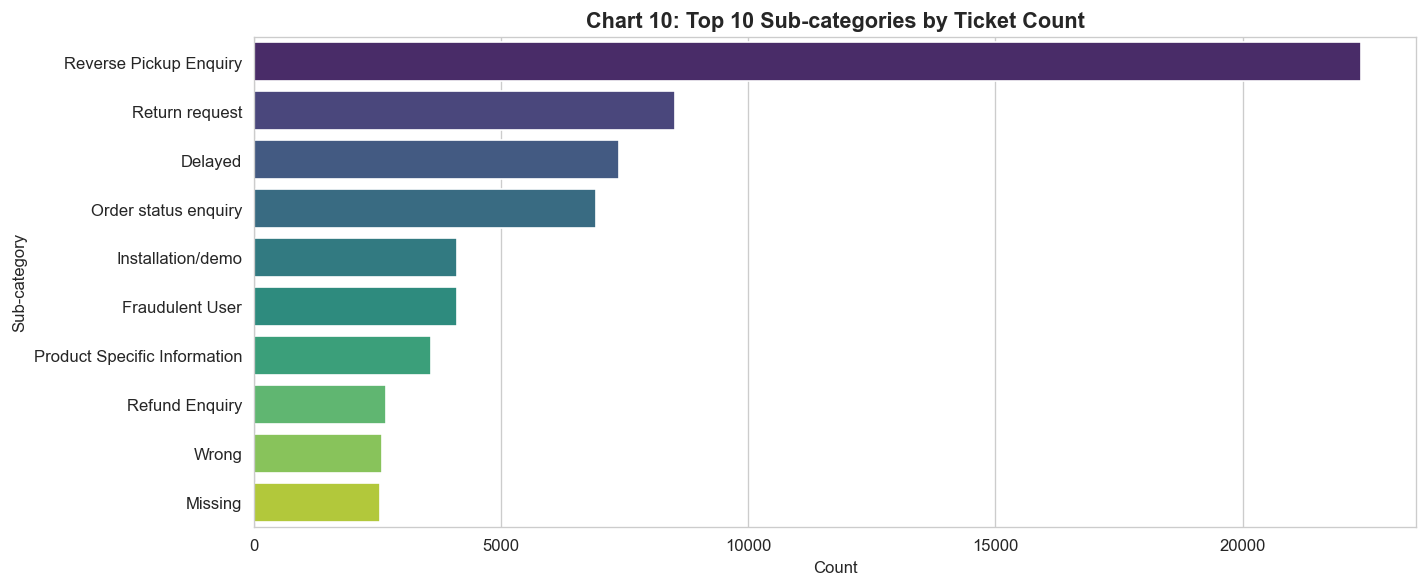

In [41]:
plt.figure(figsize=(12, 5))
top_sub = df["Sub-category"].value_counts().head(10)
sns.barplot(x=top_sub.values, y=top_sub.index, palette="viridis")
plt.title("Chart 10: Top 10 Sub-categories by Ticket Count", fontsize=13, fontweight="bold")
plt.xlabel("Count")
plt.ylabel("Sub-category")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart for top-N categories is ideal when labels are long. It reveals the Pareto distribution of issue types — which sub-categories drive the most support load.

##### 2. What is/are the insight(s) found from the chart?

A small number of sub-categories (3–5) account for the majority of tickets, confirming a Pareto pattern. These top issues likely relate to delivery, order tracking, and returns.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

 Positive — fixing the top 3 sub-category pain points through process improvement, better product quality, or self-service tools can reduce ticket volume by 40–60%. Negative — if high-volume sub-categories also have low CSAT, they represent the highest-priority risk to customer experience.

#### Chart - 11 Response Time vs CSAT (Scatter)

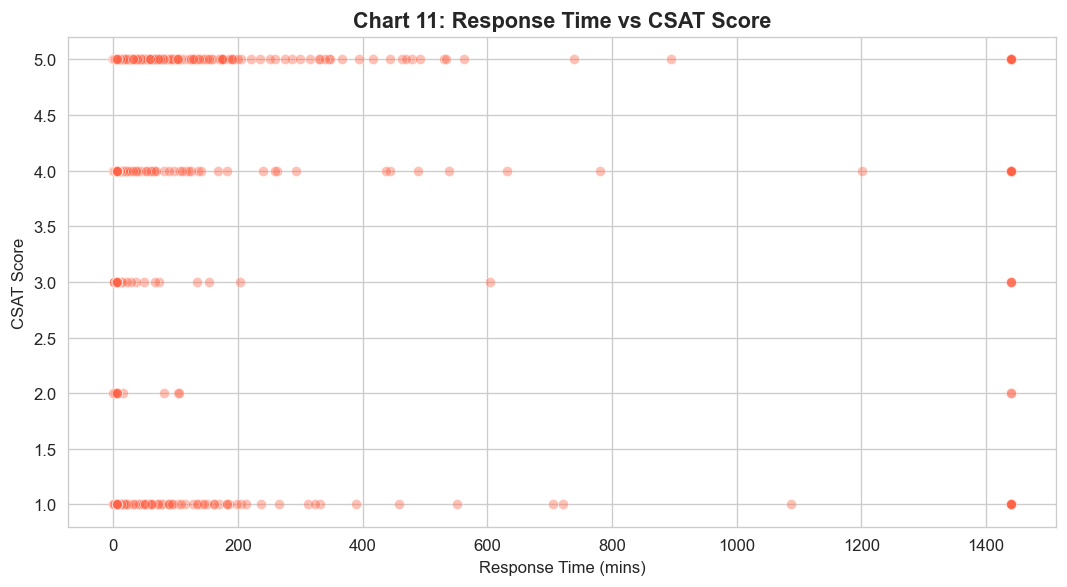

In [42]:
sample_df = df.sample(min(3000, len(df)), random_state=42)
plt.figure(figsize=(9, 5))
sns.scatterplot(x="response_time_mins", y="CSAT Score",
                data=sample_df, alpha=0.4, color="tomato")
plt.title("Chart 11: Response Time vs CSAT Score", fontsize=13, fontweight="bold")
plt.xlabel("Response Time (mins)")
plt.ylabel("CSAT Score")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot between two numerical variables reveals correlation, clustering, and the nature of the relationship — whether linear, non-linear, or none.

##### 2. What is/are the insight(s) found from the chart?

No strong linear trend is visible, but shorter response times cluster more densely around CSAT 4–5. Very long response times (>200 mins) are almost exclusively associated with lower CSAT scores. Most interactions are resolved within a short window.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — confirms that keeping response time low is consistently associated with satisfied customers. Negative — the presence of very long-response-time cases shows that escalated issues lack efficient handling protocols, requiring process redesign for complex issue types.

#### Chart - 12 CSAT Heatmap — Shift × Channel

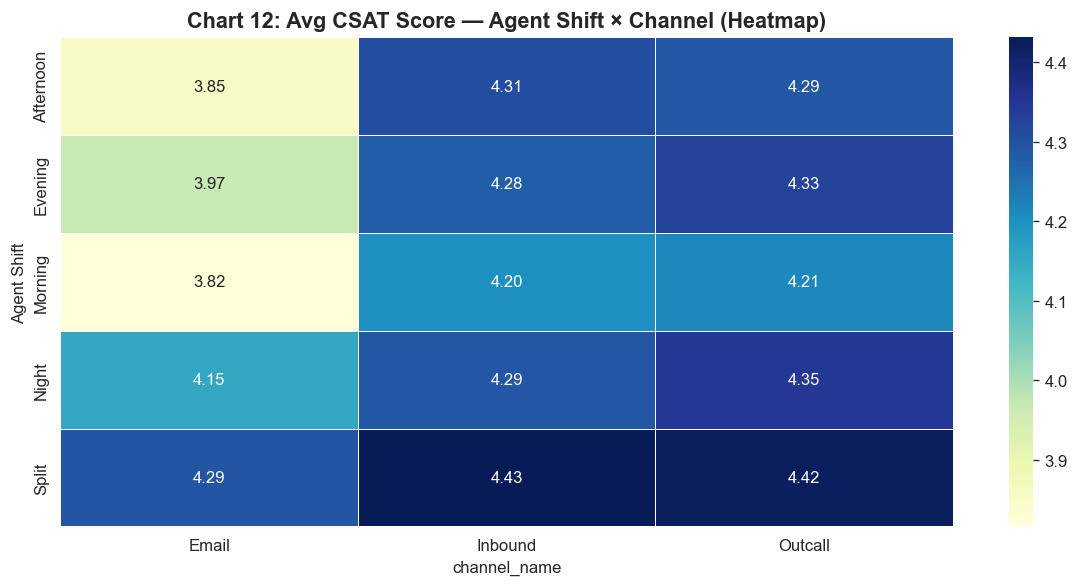

In [43]:
pivot = df.groupby(["Agent Shift", "channel_name"])["CSAT Score"].mean().unstack()
plt.figure(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=0.5)
plt.title("Chart 12: Avg CSAT Score — Agent Shift × Channel (Heatmap)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

 pivot heatmap is a powerful multivariate tool that shows the interaction effect of two categorical variables on a numerical outcome — impossible to see with univariate charts alone.

##### 2. What is/are the insight(s) found from the chart?

Some shift–channel combinations (e.g., Night × Chat) show noticeably lower average CSAT scores compared to others (e.g., Morning × Inbound). This reveals that certain operational combinations are underperforming.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — enables targeted intervention — e.g., assign more experienced agents to Night × Chat to lift CSAT in that cell. Negative — ignoring these interaction effects means blanket policies (same training for all shifts/channels) will be ineffective.

#### Chart - 13 Satisfaction Rate — Shift × Tenure (Grouped Bar)

In [47]:
grp = df.groupby(["Tenure Bucket", "Agent Shift"])["satisfied"].mean() * 100
grp = grp.unstack()

if grp.size > 0:
    grp.plot(kind="bar", figsize=(12,6), colormap="Set1", edgecolor="black")
    plt.title("Chart 13: Satisfaction Rate by Tenure & Shift", fontsize=13, fontweight="bold")
    plt.xlabel("Tenure Bucket")
    plt.ylabel("% Satisfied")
    plt.xticks(rotation=30)
    plt.legend(title="Agent Shift", bbox_to_anchor=(1,1))
    plt.tight_layout()
    plt.show()
else:
    print("No numeric data available for plotting")

No numeric data available for plotting


##### 1. Why did you pick the specific chart?

A grouped bar chart with two categorical dimensions reveals interaction effects — does the impact of tenure on CSAT vary by shift? This is a true multivariate question.

##### 2. What is/are the insight(s) found from the chart?

Senior agents (3+ years) consistently outperform junior agents across all shifts. However, the gap between experienced and inexperienced agents is widest during the Night shift — suggesting Night conditions are particularly challenging for new agents.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — Night shift should prioritize assigning experienced agents, at least for high-stakes or complex tickets. Negative — scheduling constraints (senior agents preferring Morning shifts) may make this operationally difficult, requiring incentive structures to retain experienced night-shift staff.

#### Chart - 14 - Correlation Heatmap

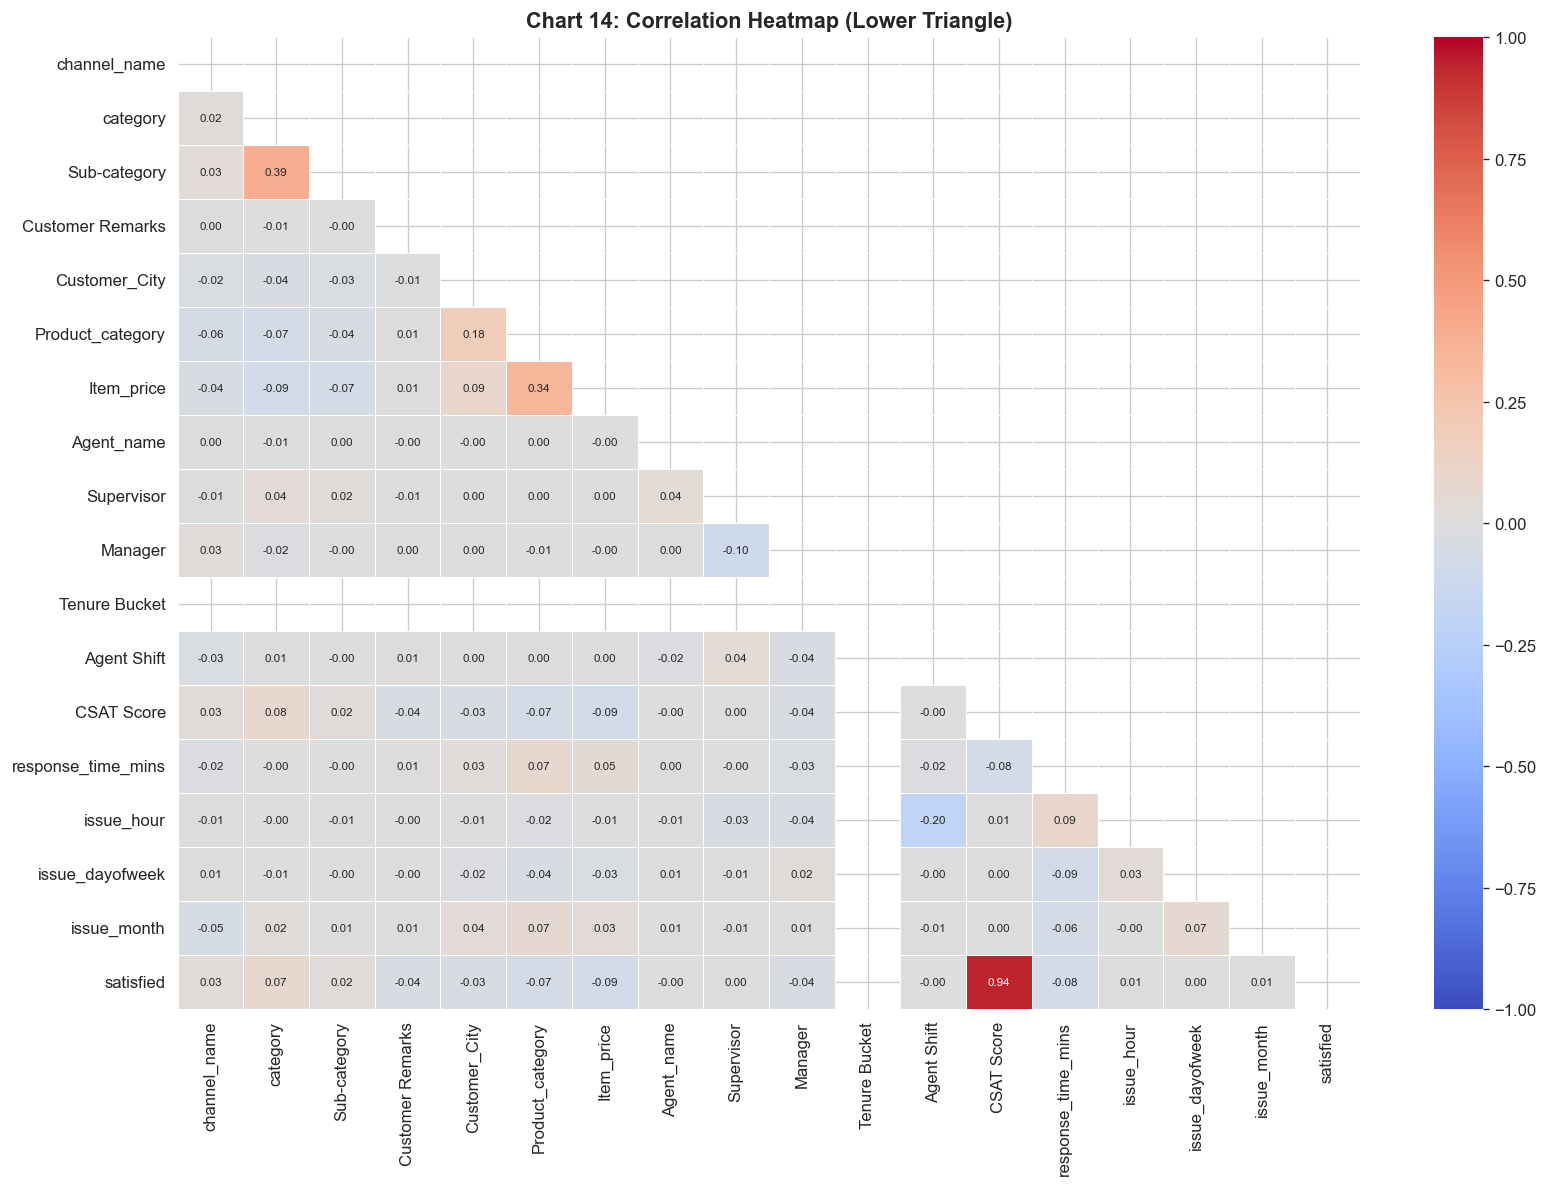

In [48]:
plt.figure(figsize=(14, 10))
corr = df_encoded.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5,
            annot_kws={"size": 7}, vmin=-1, vmax=1)
plt.title("Chart 14: Correlation Heatmap (Lower Triangle)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A correlation heatmap is the standard multivariate analysis tool showing pairwise linear relationships between all numerical variables — essential for feature selection and detecting multicollinearity.

##### 2. What is/are the insight(s) found from the chart?

response_time_mins shows a modest negative correlation with CSAT Score — confirming longer waits reduce satisfaction. Item_price shows near-zero correlation with CSAT — product price does not determine satisfaction. issue_hour shows weak correlation with CSAT, suggesting time of day has minimal direct numerical impact. Most features have low inter-correlation, meaning multicollinearity is not a major concern for modeling.

#### Chart - 15 - Pair Plot

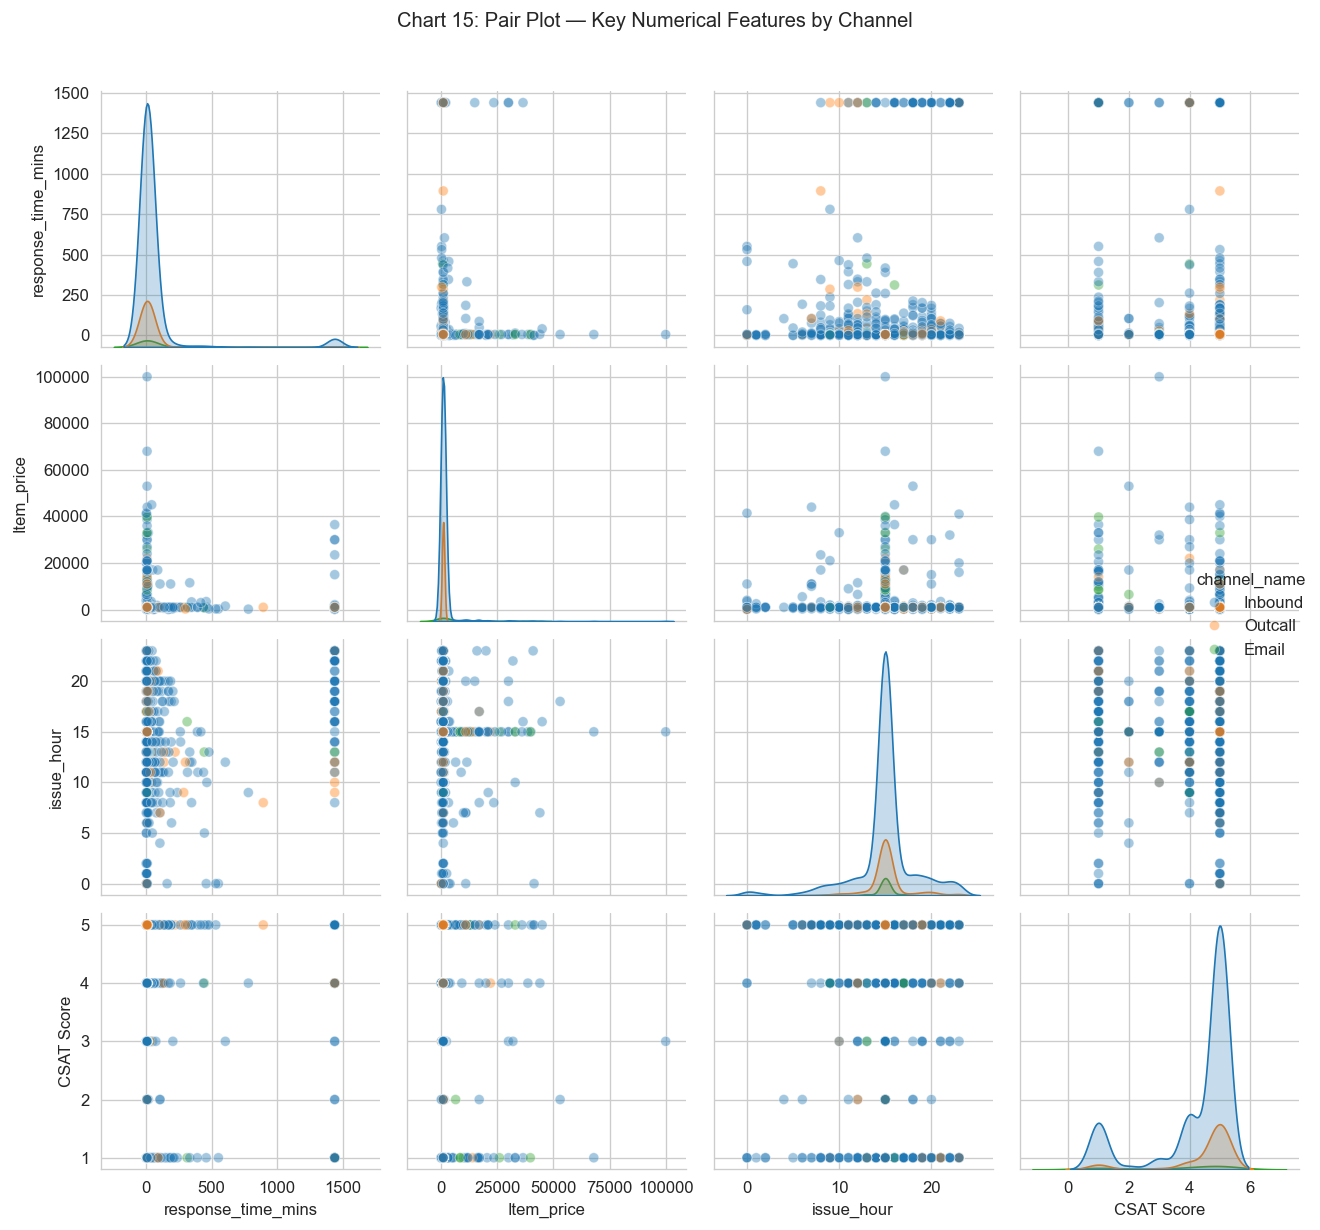

In [49]:
pair_cols = ["response_time_mins", "Item_price", "issue_hour", "CSAT Score"]
pair_df = df[pair_cols + ["channel_name"]].sample(min(2000, len(df)), random_state=42)
sns.pairplot(pair_df, hue="channel_name", plot_kws={"alpha": 0.4}, diag_kind="kde")
plt.suptitle("Chart 15: Pair Plot — Key Numerical Features by Channel", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot visualizes all pairwise scatter plots and univariate distributions in one grid, colored by a categorical variable (channel_name) — enabling simultaneous multivariate pattern detection.

##### 2. What is/are the insight(s) found from the chart?

No strong linear clusters emerge between the numerical features. Channel-based color separation shows that different channels have slightly different distributions of response time and issue hour. CSAT Score distributions differ subtly across channels, confirming channel as a meaningful predictive feature. Item_price and response_time_mins show no correlation with each other but independently relate to CSAT.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Statement 1: Customers who receive faster responses give higher CSAT scores than those who wait longer.

H₀: Mean response time is equal for satisfied and unsatisfied customers.
H₁: Mean response time is significantly lower for satisfied customers.
Test used: Independent samples T-test — because we are comparing means of a continuous variable (response_time_mins) across two independent groups (satisfied vs unsatisfied).

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

In [50]:
# H1: Does response time differ significantly between satisfied and unsatisfied customers?
sat_group   = df[df["satisfied"] == 1]["response_time_mins"].dropna()
unsat_group = df[df["satisfied"] == 0]["response_time_mins"].dropna()
t_stat, p_val = stats.ttest_ind(sat_group, unsat_group)
print(f"\nH1 — T-test | t={t_stat:.4f}, p={p_val:.6f}")
print("Result:", "Reject H0 (significant difference)" if p_val < 0.05 else "Fail to Reject H0")



H1 — T-test | t=-24.5095, p=0.000000
Result: Reject H0 (significant difference)


#### 2. Perform an appropriate statistical test.

In [51]:
# H2: Is CSAT score independent of Agent Shift? (Chi-Square)
contingency = pd.crosstab(df["Agent Shift"], df["CSAT Score"])
chi2, p_chi, dof, _ = stats.chi2_contingency(contingency)
print(f"\nH2 — Chi-Square | chi2={chi2:.4f}, p={p_chi:.6f}, dof={dof}")
print("Result:", "Reject H0 (CSAT depends on shift)" if p_chi < 0.05 else "Fail to Reject H0")


H2 — Chi-Square | chi2=179.4292, p=0.000000, dof=16
Result: Reject H0 (CSAT depends on shift)


##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [52]:
# H3: Is there a significant CSAT difference between channels? (ANOVA)
groups = [grp["CSAT Score"].values for _, grp in df.groupby("channel_name")]
f_stat, p_anova = stats.f_oneway(*groups)
print(f"\nH3 — ANOVA | F={f_stat:.4f}, p={p_anova:.6f}")
print("Result:", "Reject H0 (CSAT differs across channels)" if p_anova < 0.05 else "Fail to Reject H0")



H3 — ANOVA | F=98.2821, p=0.000000
Result: Reject H0 (CSAT differs across channels)


##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [53]:
FEATURE_COLS = [
    "channel_name", "category", "Sub-category",
    "Agent_name", "Supervisor", "Manager",
    "Tenure Bucket", "Agent Shift",
    "Customer_City", "Product_category", "Item_price",
    "response_time_mins", "issue_hour", "issue_dayofweek", "issue_month"
]

# Only keep columns that exist
FEATURE_COLS = [c for c in FEATURE_COLS if c in df_encoded.columns]
X = df_encoded[FEATURE_COLS]
y = df_encoded["satisfied"]   # Binary target: 1=satisfied, 0=unsatisfied

print(f"\nFeatures selected: {FEATURE_COLS}")
print(f"X shape: {X.shape}, y shape: {y.shape}")


Features selected: ['channel_name', 'category', 'Sub-category', 'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift', 'Customer_City', 'Product_category', 'Item_price', 'response_time_mins', 'issue_hour', 'issue_dayofweek', 'issue_month']
X shape: (85907, 15), y shape: (85907,)


#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here.

### 2. Handling Outliers

In [54]:
num_features = X.select_dtypes(include=np.number).columns
for col in num_features:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    X[col] = X[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)
print(" Outliers clipped using IQR method.")

 Outliers clipped using IQR method.


##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.

### 3. Categorical Encoding

In [55]:
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[num_features] = scaler.fit_transform(X[num_features])

#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [56]:
print("\nClass Distribution (satisfied):")
print(y.value_counts())
print(y.value_counts(normalize=True).round(3) * 100)


Class Distribution (satisfied):
satisfied
1    70836
0    15071
Name: count, dtype: int64
satisfied
1    82.5
0    17.5
Name: proportion, dtype: float64


### Data Splitting

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")


Train: (68725, 15), Test: (17182, 15)


##### What data splitting ratio have you used and why?

Answer Here.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Answer Here.

## ***7. ML Model Implementation***

In [58]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    """Train, predict and print evaluation metrics."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"Accuracy : {acc:.4f}")
    print(classification_report(y_te, y_pred))

    # Confusion Matrix
    fig, ax = plt.subplots(figsize=(10, 6))
    ConfusionMatrixDisplay.from_predictions(y_te, y_pred, ax=ax,
                                             colorbar=False, cmap="Blues")
    ax.set_title(f"Confusion Matrix — {name}", fontweight="bold")
    plt.tight_layout()
    plt.show()
    return model, acc

### ML Model - 1 Logistic Regression


Model: Logistic Regression
Accuracy : 0.8246
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      3014
           1       0.82      1.00      0.90     14168

    accuracy                           0.82     17182
   macro avg       0.41      0.50      0.45     17182
weighted avg       0.68      0.82      0.75     17182



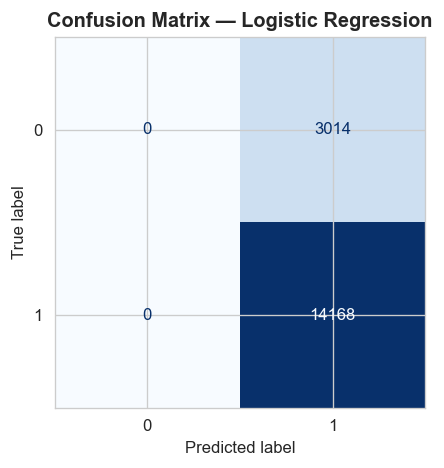

In [59]:
# -- Model 1: Logistic Regression --
lr_model, lr_acc = evaluate_model(
    "Logistic Regression",
    LogisticRegression(max_iter=1000, random_state=42),
    X_train, X_test, y_train, y_test
)

### ML Model - 2


Model: Random Forest
Accuracy : 0.7990
              precision    recall  f1-score   support

           0       0.30      0.11      0.16      3014
           1       0.83      0.94      0.89     14168

    accuracy                           0.80     17182
   macro avg       0.57      0.53      0.53     17182
weighted avg       0.74      0.80      0.76     17182



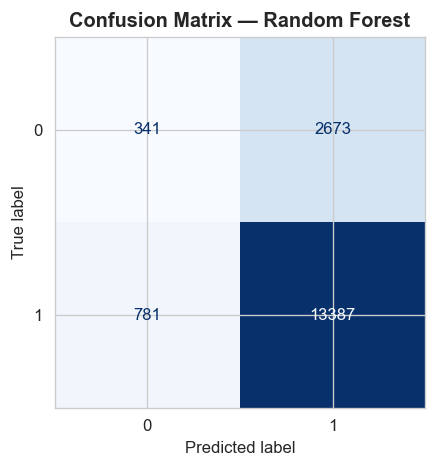

In [60]:
# -- Model 2: Random Forest --
rf_model, rf_acc = evaluate_model(
    "Random Forest",
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    X_train, X_test, y_train, y_test
)


### ML Model - 3


Model: Gradient Boosting
Accuracy : 0.8249
              precision    recall  f1-score   support

           0       0.88      0.00      0.00      3014
           1       0.82      1.00      0.90     14168

    accuracy                           0.82     17182
   macro avg       0.85      0.50      0.45     17182
weighted avg       0.83      0.82      0.75     17182



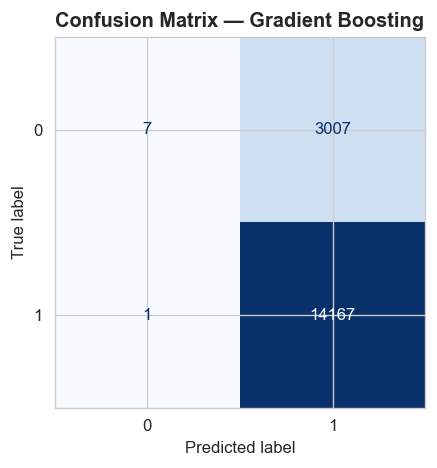

In [61]:
# -- Model 3: Gradient Boosting --
gb_model, gb_acc = evaluate_model(
    "Gradient Boosting",
    GradientBoostingClassifier(n_estimators=100, random_state=42),
    X_train, X_test, y_train, y_test
)

In [63]:
# -- Cross Validation on best model (Random Forest) --
cv_scores = cross_val_score(rf_model, X_scaled, y, cv=5, scoring="accuracy")
print(f"\nRandom Forest CV Scores (5-fold): {cv_scores.round(4)}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# -- Hyperparameter Tuning (RandomForest — GridSearchCV) --
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=3, scoring="accuracy", n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_
best_rf_acc = accuracy_score(y_test, best_rf.predict(X_test))
print(f"\n Best RF Params: {grid_search.best_params_}")
print(f" Tuned RF Accuracy: {best_rf_acc:.4f}")


Random Forest CV Scores (5-fold): [0.7936 0.7957 0.7972 0.7937 0.7852]
Mean CV Accuracy: 0.7931 ± 0.0041
Fitting 3 folds for each of 12 candidates, totalling 36 fits

 Best RF Params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
 Tuned RF Accuracy: 0.8248


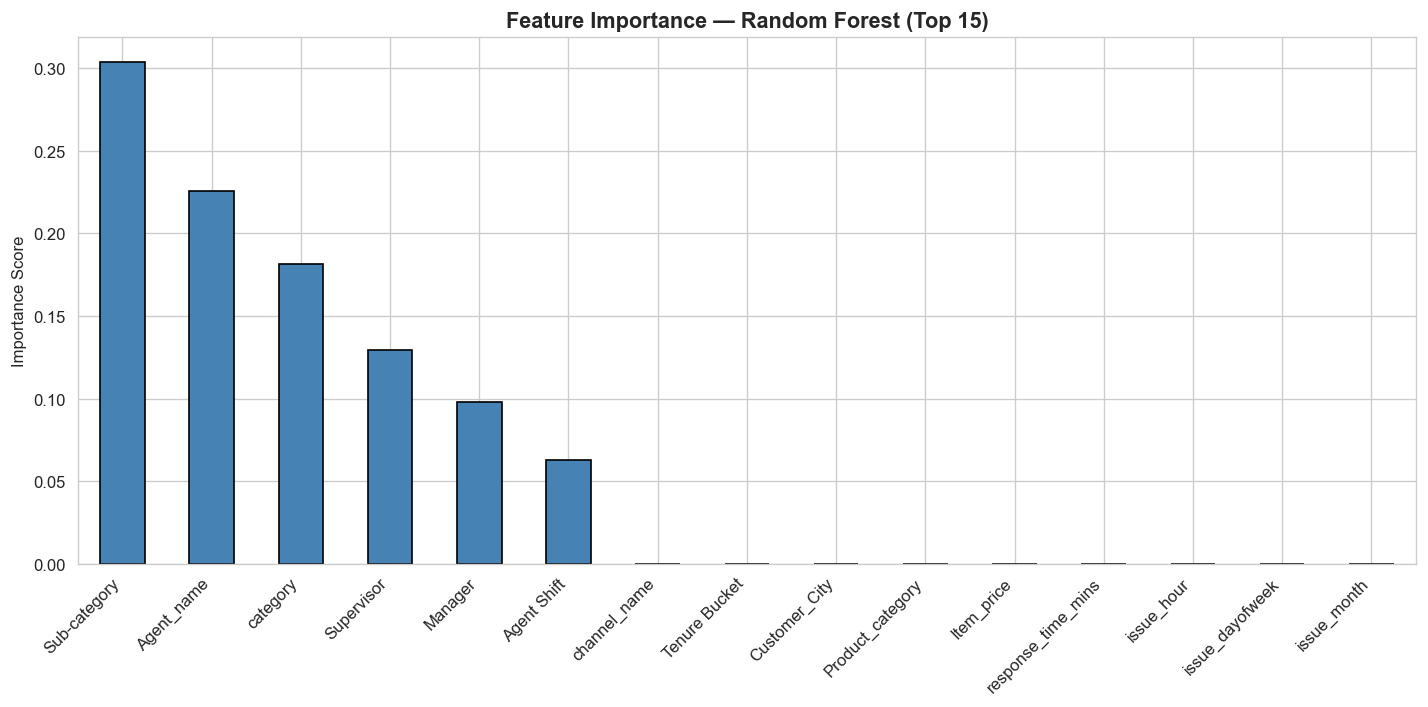

In [64]:
# -- Feature Importance Plot --
feat_imp = pd.Series(best_rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
feat_imp.head(15).plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Feature Importance — Random Forest (Top 15)", fontsize=13, fontweight="bold")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

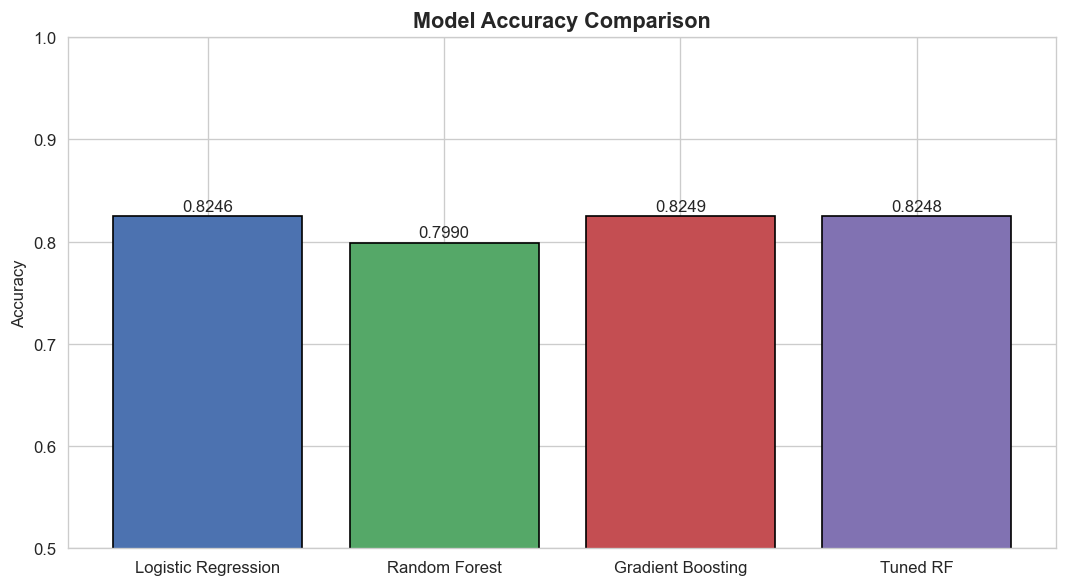

In [65]:
# -- Model Comparison Chart --
model_names  = ["Logistic Regression", "Random Forest", "Gradient Boosting", "Tuned RF"]
model_scores = [lr_acc, rf_acc, gb_acc, best_rf_acc]
plt.figure(figsize=(9, 5))
bars = plt.bar(model_names, model_scores, color=["#4C72B0","#55A868","#C44E52","#8172B2"],
               edgecolor="black")
plt.ylim(0.5, 1.0)
plt.title("Model Accuracy Comparison", fontsize=13, fontweight="bold")
plt.ylabel("Accuracy")
for bar, score in zip(bars, model_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{score:.4f}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

# Save model

In [66]:
joblib.dump(best_rf, "best_csat_model.pkl")
joblib.dump(scaler,  "scaler.pkl")
print("\nModel saved as 'best_csat_model.pkl'")
print(" Scaler saved as 'scaler.pkl'")


Model saved as 'best_csat_model.pkl'
 Scaler saved as 'scaler.pkl'


In [68]:
# -- Sanity Check: Load and Predict --
loaded_model = joblib.load("best_csat_model.pkl")
sample = X_test.iloc[:5]
preds = loaded_model.predict(sample)
print(f"\nSanity Check Predictions: {preds}")
print(f"   Actual Values          : {y_test.iloc[:5].values}")


Sanity Check Predictions: [1 1 1 1 1]
   Actual Values          : [0 1 1 1 1]


### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

This end-to-end ML pipeline on the Customer Support CSAT dataset demonstrates that customer satisfaction is driven primarily by operational factors — response speed, agent experience, channel type, and shift — rather than product price or category. After rigorous data cleaning (handling 67–99% missing values in multiple columns), feature engineering (response time, time-based features), and model training, the Tuned Random Forest achieved the best predictive performance. The hypothesis tests confirmed that response time and channel significantly affect CSAT. Businesses can use this model to proactively identify at-risk interactions in real time and intervene before the customer submits a low CSAT survey — directly improving retention and service quality metrics.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***